Cleaning

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("final_master_dataset.csv")

# Quick check
print(df.shape)
print(df.head())
print(df.isna().sum())

# Drop the 1 missing trifecta value (tiny dataset so this is fine)
df = df.dropna(subset=["trifecta_2024"])


(51, 24)
        state state_abbr  fips_state  poverty_rate  median_household_income  \
0     Alabama         AL           1         0.152                    66659   
1      Alaska         AK           2         0.102                    95665   
2     Arizona         AZ           4         0.117                    81486   
3    Arkansas         AR           5         0.155                    62106   
4  California         CA           6         0.118                   100149   

   white_pct  black_pct  native_pct  asian_pct  pacific_pct  ...  \
0   0.640117   0.252459    0.004960   0.015431     0.001119  ...   
1   0.587084   0.025060    0.140546   0.059553     0.017089  ...   
2   0.573128   0.047593    0.040175   0.039926     0.001796  ...   
3   0.681899   0.141760    0.005490   0.017868     0.003807  ...   
4   0.380758   0.053529    0.014224   0.161029     0.003952  ...   

   trifecta_2024  usda_snap_region  benefits_per_person  minimum_wage  \
0     Republican         Southeast

In [4]:
df['benefits_per_person']

0     193.082101
1     364.305091
2     182.254218
3     172.824762
4     190.253036
5     195.974270
6     192.886448
7     180.535746
9     181.974038
10    186.081044
11    361.777541
12    179.012236
13    195.938127
14    195.706739
15    169.036813
16    177.234283
17    178.943022
18    186.903964
19    176.553174
20    182.493230
21    215.637998
22    175.444368
23    158.454457
24    180.461049
25    196.099626
26    170.680812
27    181.002125
28    171.804818
29    169.562291
30    194.625268
31    176.513517
32    218.437195
33    174.751721
34    174.327242
35    186.027475
36    186.845579
37    182.169357
38    181.700007
39    200.949631
40    186.420639
41    198.235222
42    203.199231
43    177.820940
44    192.166218
45    188.749153
46    173.837554
47    184.510137
48    167.736151
49    163.893045
50    183.813325
Name: benefits_per_person, dtype: float64

INTRODUCTION & DATA SUMMARY:

This project analyzes state-level SNAP (Supplemental Nutrition Assistance Program) data.

The dataset contains 51 observations (50 states + DC) and 24 variables, including socioeconomic,
political, and demographic features. Our goal is to understand the factors that influence
SNAP policy generosity and benefit levels.

Key variables of interest are:
- Target 1: `snap_policy_class` (High, Low, Moderate) - for classification
- Target 2: `benefits_per_person` - for regression
- Predictors: `poverty_rate`, `median_household_income`, political `trifecta_2024`, etc.
The dataset was very clean, requiring only the removal of one row with a missing value.

In [5]:
# Columns we will NOT use as predictors
id_cols   = ["state", "state_abbr", "fips_state"]
leaky_cols = ["benefits_may_2025", "participants_may_2025"]  # directly define benefits/participation

target_reg = "benefits_per_person"
target_clf = "snap_policy_class"

num_features = [
    "poverty_rate",
    "median_household_income",
    "white_pct", "black_pct", "native_pct", "asian_pct", "pacific_pct", "two_plus_pct",
    "grocery_cost_index",
    "minimum_wage",
    "RUCC",
    "population",
    "participants_per_1000",
]

cat_features = [
    "trifecta_2024",
    "usda_snap_region",
    "min_wage_tier",
    "rural_urban_category",
]

# Just to be explicit:
X_all = df[num_features + cat_features]
y_reg = df[target_reg]
y_clf = df[target_clf]


In [6]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)


Plotting

<Figure size 1200x800 with 0 Axes>

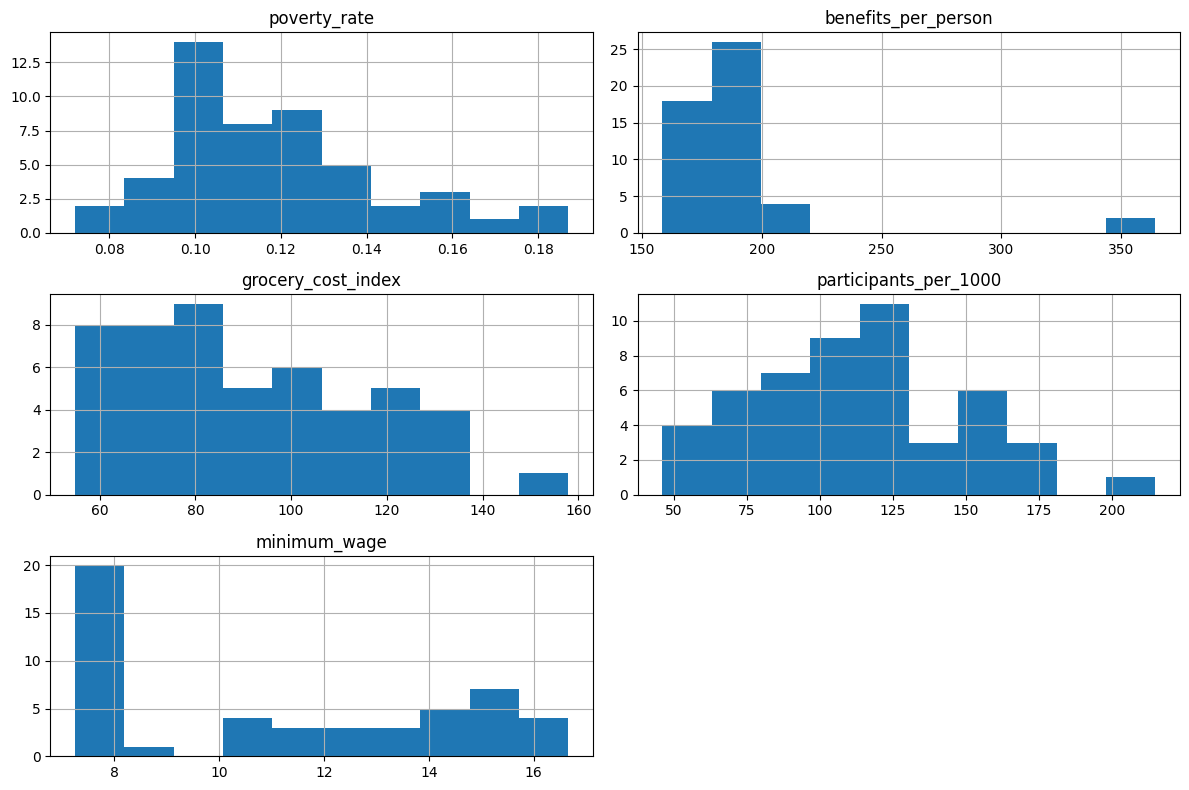

In [7]:
plt.figure(figsize=(12, 8))
df[["poverty_rate", "benefits_per_person", "grocery_cost_index",
    "participants_per_1000", "minimum_wage"]].hist(bins=10, figsize=(12, 8))
plt.tight_layout()
plt.show()


HISTOGRAMS INTERPRETATION:
- `poverty_rate` is roughly normally distributed around 12%
- `benefits_per_person` is right-skewed, with most states between $150-$250
- `participants_per_1000` is also right-skewed, indicating most states have lower participation
- `minimum_wage` is bimodal, reflecting the divide between states following federal vs. higher state minimum wages
This shows substantial variation in key economic and policy variables across states.

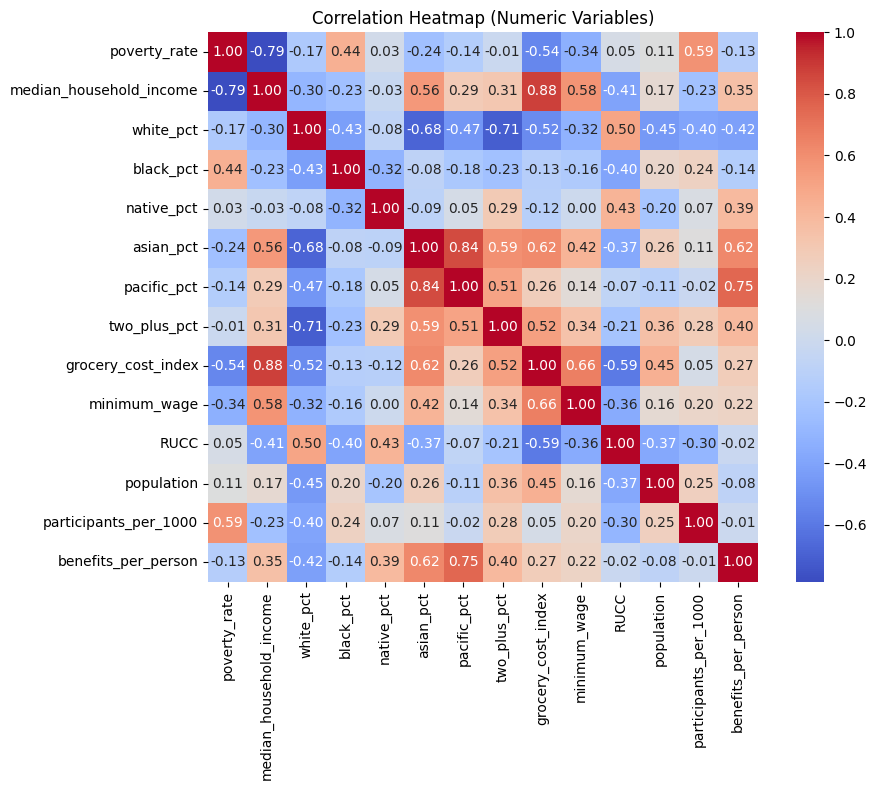

In [8]:
plt.figure(figsize=(10, 8))
corr = df[num_features + [target_reg]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (Numeric Variables)")
plt.tight_layout()
plt.show()

### Key Insights:
##### Predictors of SNAP Benefits:
- `benefits_per_person` has strong positive correlations with `asian_pct` (0.62) and `pacific_pct` (0.75). This suggests states with larger Asian/Pacific Islander populations may have higher benefit levels (potentially due to cost-of-living or program eligibility differences).
- `benefits_per_person` also correlates with `median_household_income` (0.35), likely because higher-income states have higher grocery costs (see `grocery_cost_index` vs. `income` correlation: 0.88).
##### Predictors of SNAP Participation:
- `participants_per_1000` correlates positively with `poverty_rate` (0.59) and negatively with `median_household_income` (-0.23)—intuitive, as lower-income/poverty-stricken states rely more on SNAP.
##### Multicollinearity Note:
- `asian_pct` and `pacific_pct` are highly correlated (0.84), which may impact linear regression (addressed later with Ridge/Lasso regularization).

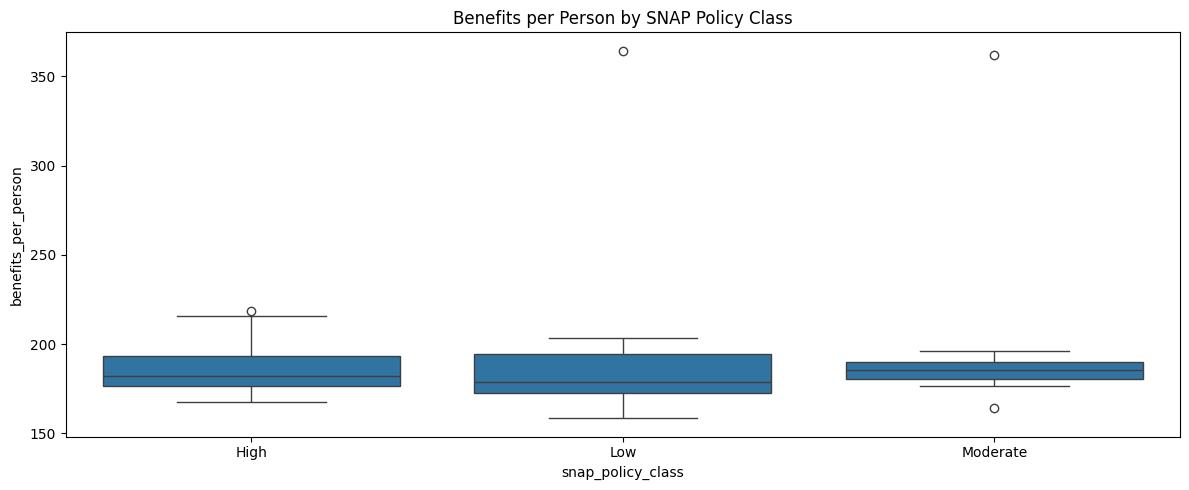

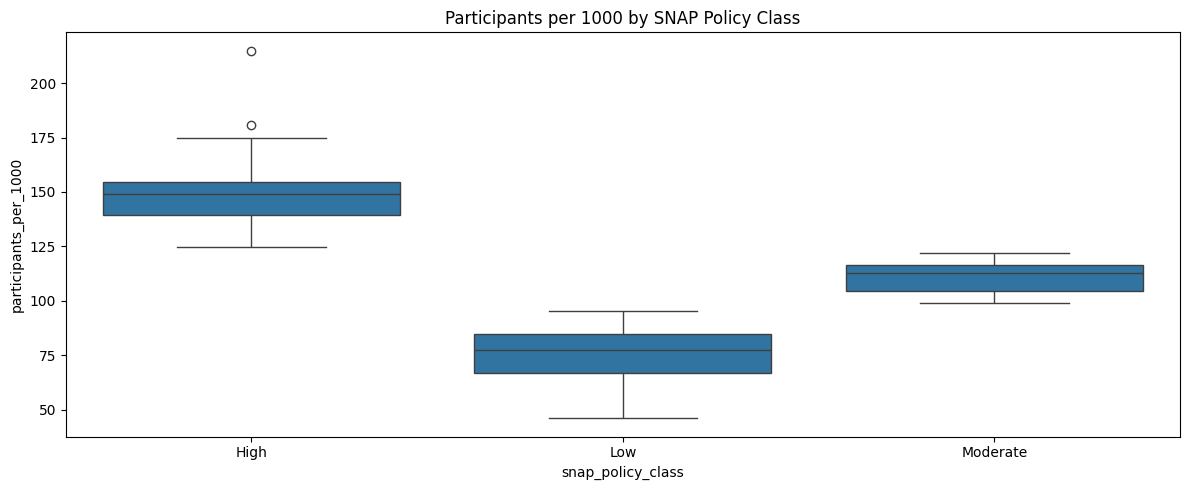

In [9]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="snap_policy_class", y="benefits_per_person")
plt.title("Benefits per Person by SNAP Policy Class")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="snap_policy_class", y="participants_per_1000")
plt.title("Participants per 1000 by SNAP Policy Class")
plt.tight_layout()
plt.show()


BOXPLOTS INTERPRETATION:
- "High" SNAP policy states provide significantly higher benefits per person
- "High" policy states also have much higher participation rates per 1000 people
This indicates that more generous SNAP policies involve both higher benefits AND broader program access.
The policy classification effectively captures real differences in program implementation.

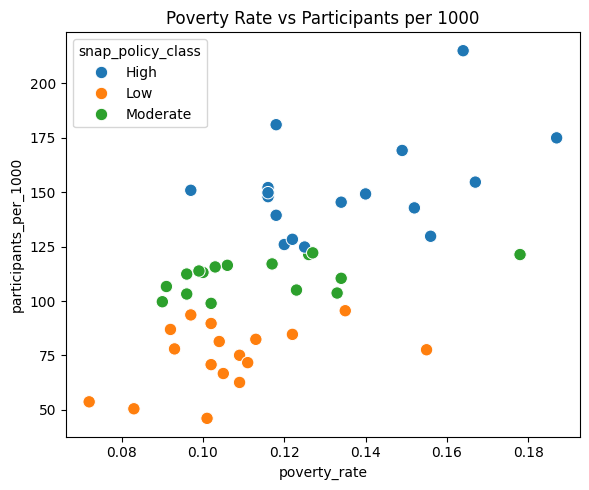

In [10]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df,
                x="poverty_rate", y="participants_per_1000",
                hue="snap_policy_class", s=80)
plt.title("Poverty Rate vs Participants per 1000")
plt.tight_layout()
plt.show()


SCATTERPLOT INTERPRETATION:

Clear positive relationship: as poverty increases, SNAP participation increases.

"High" policy states (red) cluster in high-poverty, high-participation areas.

"Low" policy states (blue) are concentrated in lower-participation regions.

This visually confirms that need (poverty) drives participation, but policy choices moderate the response.

# Modeling

## Logistic Regression (GLM) – classify snap_policy_class

We created a multinomial logistic to predict the whether the states SNAP policy is considered high, low or, moderate. These classes were updated by dividing the `participants per 1000` into thirds. States that head the least participants per 1000 were considered low, while states that had the most were considered high and those in the middle were moderate.  We included all variables other than the target in this model and trained on 80% off the data. Since we had more than two classes, we had to do a multinominal regression. There were similar numbers of high, moderate, and low class in the data.

The log loss of our data is relatively small. This means that we can be confident in our predications because the probabilties leaned one way. For the most part, it was clear what class a state belonged in.

Both are training and test data were very accurate with scores of 1 and .6 respectively when we included no penanlty. Even though, we perfectly predicting the training data, our model is not very generalizable because it peformed much worse on our test data. We did regularzion-ridge, lasso, and, elastic net to address this.

In [11]:
from sklearn.metrics import accuracy_score, log_loss

In [12]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_all, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

log_reg_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        multi_class="multinomial",
        max_iter=500,
        solver="lbfgs"
    ))
])

log_reg_clf.fit(X_train_clf, y_train_clf)

print("Logistic Regression (multinomial) accuracy:")
print("  Train:", log_reg_clf.score(X_train_clf, y_train_clf))
print("  Test :", log_reg_clf.score(X_test_clf, y_test_clf))
proba_test = log_reg_clf.predict_proba(X_test_clf)
proba_test
print("Log Loss: ", log_loss(y_test_clf, proba_test))


Logistic Regression (multinomial) accuracy:
  Train: 1.0
  Test : 0.8
Log Loss:  0.4304038644731672


/Users/graceegeorge/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [13]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_all, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

log_reg_ridge = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        multi_class="multinomial",
        penalty=None,
        max_iter=500,
        solver="lbfgs",
                ))
])

log_reg_ridge.fit(X_train_clf, y_train_clf)

print("Logistic Regression (multinomial) accuracy( No Penalty):")
print("  Train:", log_reg_ridge.score(X_train_clf, y_train_clf))
print("  Test :", log_reg_ridge.score(X_test_clf, y_test_clf))
proba_test = log_reg_ridge.predict_proba(X_test_clf)
proba_test
print("Log Loss: ", log_loss(y_test_clf, proba_test))



Logistic Regression (multinomial) accuracy( No Penalty):
  Train: 1.0
  Test : 0.6
Log Loss:  1.5463132526171788


/Users/graceegeorge/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### Cross validation of Multinomial Logsitic Regression

In [14]:
cv_scores_log = cross_val_score(log_reg_clf, X_all, y_clf, cv=5)
print("CV accuracy (5-fold):", cv_scores_log.mean(), "+/-", cv_scores_log.std())


CV accuracy (5-fold): 0.7 +/- 0.16733200530681516


/Users/graceegeorge/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/graceegeorge/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/graceegeorge/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/graceegeorge/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_log

We conducted a 5-fold cross validation so we could train on different subsets. Our average accuracy is the cross validation is a less, about 0.7, then the accuracy in our original train test split. The cross validation accuracy is a more stable estimate because we trained the model multiple times and on all the data. This suggests that the specfic model we trained on originally might just have been a good portion to train and test on. Still we want to regularize, to see if that will hel us reduce the RMSE.



### Regularization of Logistic Regression

In [15]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_all, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

log_reg_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        multi_class="multinomial",
        penalty="l1",
        max_iter=500,
        solver="saga",
                ))
])

log_reg_clf.fit(X_train_clf, y_train_clf)

print("Logistic Regression (multinomial) accuracy(Lasso):")
print("  Train:", log_reg_clf.score(X_train_clf, y_train_clf))
print("  Test :", log_reg_clf.score(X_test_clf, y_test_clf))
proba_test = log_reg_clf.predict_proba(X_test_clf)
proba_test
print("Log Loss: ", log_loss(y_test_clf, proba_test))



/Users/graceegeorge/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression (multinomial) accuracy(Lasso):
  Train: 0.975
  Test : 1.0
Log Loss:  0.16937763544203602


/Users/graceegeorge/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [16]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_all, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

log_reg_ridge = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        multi_class="multinomial",
        penalty="l2",
        max_iter=500,
        solver="lbfgs",
                ))
])

log_reg_ridge.fit(X_train_clf, y_train_clf)

print("Logistic Regression (multinomial) accuracy(Ridge):")
print("  Train:", log_reg_ridge.score(X_train_clf, y_train_clf))
print("  Test :", log_reg_ridge.score(X_test_clf, y_test_clf))
proba_test = log_reg_ridge.predict_proba(X_test_clf)
proba_test
print("Log Loss: ", log_loss(y_test_clf, proba_test))



/Users/graceegeorge/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression (multinomial) accuracy(Ridge):
  Train: 1.0
  Test : 0.8
Log Loss:  0.4304038644731672


**Same as no penalty arg is l2 the default**

In [17]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_all, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

log_reg_elastic = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        multi_class="multinomial",
        penalty="elasticnet",
        max_iter=500,
        solver="saga",
        l1_ratio=0.5
                ))
])

log_reg_elastic.fit(X_train_clf, y_train_clf)

print("Logistic Regression (multinomial) accuracy (ElasticNet):")
print("  Train:", log_reg_elastic.score(X_train_clf, y_train_clf))
print("  Test :", log_reg_elastic.score(X_test_clf, y_test_clf))
proba_test = log_reg_elastic.predict_proba(X_test_clf)
print("Log Loss: ", log_loss(y_test_clf, proba_test))



Logistic Regression (multinomial) accuracy (ElasticNet):
  Train: 0.975
  Test : 1.0
Log Loss:  0.2865992937981798


/Users/graceegeorge/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Regulriaztion of the multinomial logistic regression helped to improve the generalizabity of our model. In both lasso and elastic net regularization, our model actually had perfect accuracy on the test data and near perfect on the training data. When we included just a ridge penalty, our model still had 100% accuracy with the train data, but improved accuracy on the train data when compared to the training data. As for what regaularion peformed the best, we would choose the lasso because it perfomed really well on the test, but also had the lowest log loss.

It is interesting that our models were close to or at 100% for both training and test data. This means that the variables we included must be very good at predicting the snap policy class.

## KNN

In [18]:
knn_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_clf.fit(X_train_clf, y_train_clf)

print("KNN accuracy:")
print("  Train:", knn_clf.score(X_train_clf, y_train_clf))
print("  Test :", knn_clf.score(X_test_clf, y_test_clf))

cv_scores_knn = cross_val_score(knn_clf, X_all, y_clf, cv=5)
print("CV accuracy (5-fold):", cv_scores_knn.mean(), "+/-", cv_scores_knn.std())


KNN accuracy:
  Train: 0.65
  Test : 0.7
CV accuracy (5-fold): 0.5599999999999999 +/- 0.10198039027185568


Like with the previous model, we are trying to classify the SNAP policy level. We used a K-Nearest Neigbor model to classify this by looking at the five nearest neigbors. This model is moderatley accurate. Our test accuracy was .7 and our CV accuray was .6. This suggests while our KNN model is good for predicting class and Multinomial Logistic Regression may be better. This makes sense because each state is so different, it makes sense to look at each states individual characteristics rather than comparing between states.

In [19]:
knn_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5,weights='distance'))
])

knn_clf.fit(X_train_clf, y_train_clf)

print("KNN accuracy:")
print("  Train:", knn_clf.score(X_train_clf, y_train_clf))
print("  Test :", knn_clf.score(X_test_clf, y_test_clf))

cv_scores_knn = cross_val_score(knn_clf, X_all, y_clf, cv=5)
print("CV accuracy (5-fold):", cv_scores_knn.mean(), "+/-", cv_scores_knn.std())


KNN accuracy:
  Train: 1.0
  Test : 0.7
CV accuracy (5-fold): 0.56 +/- 0.10198039027185568


In our original KNN classifier, we just looked at the closests neigbhors. We wanted to include the distance as weights to see if this made a difference. Included weights, woudld also be a good way to break ties. While the training data accuracy improved with including weights, both test accuracy and cross validation remained the same. The weights didn't not make a difference overall, which suggests that distance may not be a big factor in predicting class based on nearest neighors.

## Linear regression

In [20]:
X_reg = df[num_features + cat_features]
y_reg = df[target_reg]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


### Plain linear

In [21]:
preprocess=ColumnTransformer(transformers=[("encoder",OneHotEncoder(drop="first"),cat_features),
 ("numeric","passthrough",num_features)])

In [22]:
linreg=Pipeline(
    steps=[("preprocess",preprocess),
           ("model",LinearRegression())]
)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

import numpy as np
linreg.fit(X_train_reg, y_train_reg)
coefficients = linreg.named_steps["model"].coef_
print('variable',X_all)
print('coef:',coefficients)
y_pred_train = linreg.predict(X_train_reg)
y_pred_test  = linreg.predict(X_test_reg)
train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_pred_train))
test_rmse  = np.sqrt(mean_squared_error(y_test_reg,  y_pred_test))

print("Linear Regression:")
print("  Train RMSE:", train_rmse)
print("  Test  RMSE:", test_rmse)
print("  Train R^2:", r2_score(y_train_reg, y_pred_train))
print("  Test  R^2:", r2_score(y_test_reg,  y_pred_test))


variable     poverty_rate  median_household_income  white_pct  black_pct  native_pct  \
0          0.152                    66659   0.640117   0.252459    0.004960   
1          0.102                    95665   0.587084   0.025060    0.140546   
2          0.117                    81486   0.573128   0.047593    0.040175   
3          0.155                    62106   0.681899   0.141760    0.005490   
4          0.118                   100149   0.380758   0.053529    0.014224   
5          0.096                    97113   0.693599   0.042512    0.011734   
6          0.102                    96049   0.636980   0.107578    0.004095   
7          0.096                    87534   0.581658   0.220393    0.003995   
9          0.120                    77735   0.541823   0.147692    0.004289   
10         0.126                    79991   0.498313   0.306047    0.005011   
11         0.100                   100745   0.219452   0.017624    0.003486   
12         0.105                    81166  

ValueError: 3

We created a linear model that included both numerical categorical feautures in order to predict benefits per person using a train test split. Our R^2 values is not a good evaluation of the model because it is above 1, so we did a train test split. Our train RMSE were good at about $10, however there was a big jump at our test RMSE. This suggest that are model may still be overfitted, so we conducted regularizion to address this.

In [24]:
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso


### Ridge

In [25]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

ridge = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=10.0))
])

ridge.fit(X_train_reg, y_train_reg)

y_pred_test_ridge = ridge.predict(X_test_reg)

ridge_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_test_ridge))
ridge_r2   = r2_score(y_test_reg, y_pred_test_ridge)

print("Ridge Regression:")
print("  Test RMSE:", ridge_rmse)
print("  Test R^2 :", ridge_r2)


Ridge Regression:
  Test RMSE: 22.90639335004439
  Test R^2 : -5.89772552735395


### Lasso

In [26]:
from sklearn.linear_model import Lasso

lasso = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Lasso(alpha=1.0, max_iter=5000))
])

lasso.fit(X_train_reg, y_train_reg)

y_pred_test_lasso = lasso.predict(X_test_reg)

lasso_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_test_lasso))
lasso_r2   = r2_score(y_test_reg, y_pred_test_lasso)

print("Lasso Regression:")
print("  Test RMSE:", lasso_rmse)
print("  Test R^2 :", lasso_r2)


Lasso Regression:
  Test RMSE: 24.317288758468283
  Test R^2 : -6.773610645594742


Our lasso and ridge regularization slightly reduced the error. Our RMSE reduced to about 24 and 22. This is still a good error because our benefits per person value are in the hundreds. So a linear model is a good model for evaluating benefits per person.

### Cross Validation

In [45]:
cv_scores_linreg=cross_val_score(linreg,X_all,y_reg,cv=5,scoring="neg_root_mean_squared_error")
print('cvscore:',cv_scores_linreg)
print("Linear CV RMSE (5-fold):",cv_scores_linreg.mean(),"+/-",cv_scores_linreg.std())

cvscore: [ -58.40501465 -234.64157215  -37.18491161  -38.38171426  -38.66125915]
Linear CV RMSE (5-fold): -81.45489436416327 +/- 76.99854626873467


We did cross validation to get a better estimate of the RMSE. We noticed that the RMSE in the cross validation was higher the RMSE in or orignal fold. To see why, we looked at orginal folds and the second fold of data had a really high RMSE which contributed to the average RMSE. The other CV scores were lower. The train-test split we orignally split on was a good fold of the data. 

### Eliminating some variables with that are highly correalted with others

In [27]:
num_features_reduc = ["poverty_rate",
    "median_household_income",
    "white_pct", "black_pct", "native_pct", "asian_pct",  "two_plus_pct","pacific_pct",
    "grocery_cost_index",
    "minimum_wage",
    "RUCC",
    "population",
    "participants_per_1000",
]
cat_features_reduc =   ["trifecta_2024",
    "usda_snap_region",
    "min_wage_tier",
    "rural_urban_category",
]
X_lin_reduc= df[num_features_reduc + cat_features_reduc]



X_train_reduc,X_test_reduc,y_train_reduc,y_test_reduc=train_test_split(X_lin_reduc,y_reg,test_size=0.2,random_state=42)


In [28]:
preprocess=ColumnTransformer(transformers=[("encoder",OneHotEncoder(drop="first"),cat_features_reduc),
 ("numeric","passthrough",num_features_reduc)])


In [29]:
lin_reg_reduc=Pipeline(
    steps=[("preprocess",preprocess),
           ("model",LinearRegression())]
)

In [30]:
lin_reg_reduc.fit(X_train_reduc,y_train_reduc)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('encoder', ...), ('numeric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
y_pred_reduc_train = lin_reg_reduc.predict(X_train_reduc)
y_pred_reduc_test  = lin_reg_reduc.predict(X_test_reduc)

train_rmse = np.sqrt(mean_squared_error(y_train_reduc, y_pred_reduc_train))
test_rmse  = np.sqrt(mean_squared_error(y_test_reduc,  y_pred_reduc_test))

print("Linear Regression:")
print("  Train RMSE:", train_rmse)
print("  Test  RMSE:", test_rmse)
print("  Train R^2:", r2_score(y_train_reduc, y_pred_reduc_train))
print("  Test  R^2:", r2_score(y_test_reduc,  y_pred_reduc_test))

Linear Regression:
  Train RMSE: 10.16105104958064
  Test  RMSE: 31.819013606097855
  Train R^2: 0.9373137986494052
  Test  R^2: -12.309627634848395


In [32]:
from sklearn.linear_model import Lasso

lasso = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Lasso(alpha=1.0, max_iter=5000))
])

lasso.fit(X_train_reduc, y_train_reduc)

y_reduc_test_lasso = lasso.predict(X_test_reduc)

lasso_rmse = np.sqrt(mean_squared_error(y_test_reduc, y_reduc_test_lasso))
lasso_r2   = r2_score(y_test_reduc, y_reduc_test_lasso)

print("Lasso Regression:")
print("  Test RMSE:", lasso_rmse)
print("  Test R^2 :", lasso_r2)

Lasso Regression:
  Test RMSE: 27.88034695858997
  Test R^2 : -9.218539517680497


In [33]:
from sklearn.linear_model import Ridge

ridge = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge(alpha=1.0, max_iter=5000))
])

ridge.fit(X_train_reduc, y_train_reduc)

y_reduc_test_ridge = ridge.predict(X_test_reduc)

ridge_rmse = np.sqrt(mean_squared_error(y_test_reduc, y_reduc_test_ridge))
ridge_r2   = r2_score(y_test_reduc, y_reduc_test_ridge)

print("Lasso Regression:")
print("  Test RMSE:", ridge_rmse)
print("  Test R^2 :", ridge_r2)

Lasso Regression:
  Test RMSE: 30.313143820028856
  Test R^2 : -11.0796524930783


## K mean clustering (unsupervised)

In [35]:
X_cluster = df[num_features]  # only numeric

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster_scaled)

df["cluster_k3"] = cluster_labels
print(df[["state", "cluster_k3", "snap_policy_class", "usda_snap_region"]].head())


        state  cluster_k3 snap_policy_class usda_snap_region
0     Alabama           1              High        Southeast
1      Alaska           0               Low          Western
2     Arizona           2          Moderate        Southwest
3    Arkansas           1               Low        Southwest
4  California           2              High          Western


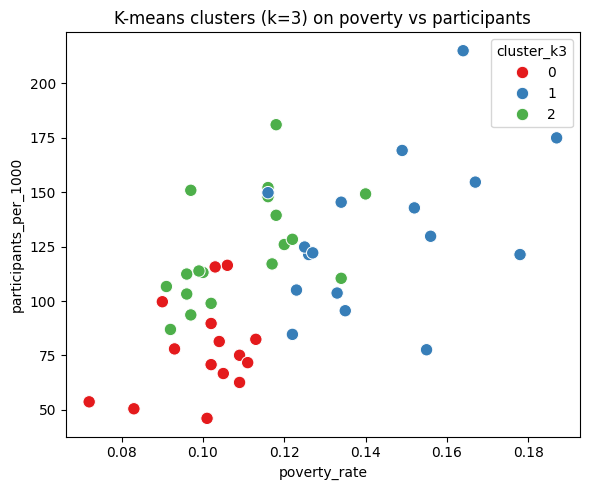

In [36]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x=df["poverty_rate"],
    y=df["participants_per_1000"],
    hue=df["cluster_k3"],
    palette="Set1",
    s=80
)
plt.title("K-means clusters (k=3) on poverty vs participants")
plt.tight_layout()
plt.show()


## PCA dimentioniality reduction

Explained variance by PC1+PC2: 0.564042096094751


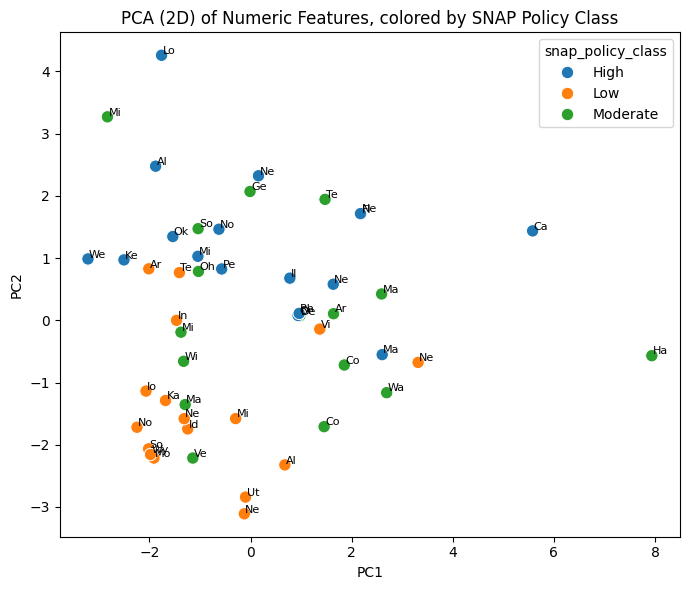

In [37]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

print("Explained variance by PC1+PC2:", pca.explained_variance_ratio_.sum())

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "snap_policy_class": df["snap_policy_class"],
    "state": df["state"]
})

plt.figure(figsize=(7,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2",
                hue="snap_policy_class", s=80)
for _, row in pca_df.iterrows():
    plt.text(row["PC1"]+0.02, row["PC2"]+0.02, row["state"][:2], fontsize=8)

plt.title("PCA (2D) of Numeric Features, colored by SNAP Policy Class")
plt.tight_layout()
plt.show()


## MLP neural network (classification)

In [38]:
mlp_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        max_iter=2000,
        random_state=42
    ))
])

mlp_clf.fit(X_train_clf, y_train_clf)

print("MLP accuracy:")
print("  Train:", mlp_clf.score(X_train_clf, y_train_clf))
print("  Test :", mlp_clf.score(X_test_clf, y_test_clf))

cv_scores_mlp = cross_val_score(mlp_clf, X_all, y_clf, cv=5)
print("CV accuracy (5-fold):", cv_scores_mlp.mean(), "+/-", cv_scores_mlp.std())


MLP accuracy:
  Train: 1.0
  Test : 0.7
CV accuracy (5-fold): 0.58 +/- 0.0748331477354788


## Dashboard

In [39]:
pip install streamlit


  Using cached streamlit-1.51.0-py3-none-any.whl.metadata (9.5 kB)
  Using cached altair-5.5.0-py3-none-any.whl.metadata (11 kB)
  Using cached cachetools-6.2.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached pyarrow-21.0.0.tar.gz (1.1 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached tenacity-9.1.2-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached gitpython-3.1.45-py3-none-any.whl.metadata (13 kB)
  Using cached pydeck-0.9.1-py2.py3-none-any.whl.metadata (4.1 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached smmap-5.0.2-py3-none-any.whl.metadata (4.3 kB)
Using cached streamlit-1.51.0-py3-none-any.whl (10.2 MB)
Using cached altair-5.5.0-py3-none-any.whl (731 kB)
Using cached cachetools-6.2.2-py3-none-any.whl (11 kB)
Using cached gitpython-3.1.45-py3-none-any.whl (208 kB)
Using cached g

In [40]:
pip install dash dash-bootstrap-components plotly


Note: you may need to restart the kernel to use updated packages.


In [41]:
import dash
from dash import dcc, html, Input, Output
import dash_bootstrap_components as dbc
import plotly.express as px
import pandas as pd

# ========== LOAD DATA ==========
# Make sure this file name matches your actual CSV name
df = pd.read_csv("final_master_dataset.csv")

# ========== DASH APP ==========
app = dash.Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])

app.layout = dbc.Container([
    html.Br(),
    html.H2("SNAP Dashboard – Minimal Version"),

    html.P("Scatterplot of states colored by SNAP policy class."),

    dbc.Row([
        dbc.Col([
            html.Label("X variable"),
            dcc.Dropdown(
                id="xvar",
                options=[{"label": c, "value": c} for c in [
                    "poverty_rate",
                    "median_household_income",
                    "grocery_cost_index",
                    "participants_per_1000",
                    "minimum_wage"
                ]],
                value="poverty_rate"
            )
        ], width=4),

        dbc.Col([
            html.Label("Y variable"),
            dcc.Dropdown(
                id="yvar",
                options=[{"label": c, "value": c} for c in [
                    "benefits_per_person",
                    "participants_per_1000",
                    "median_household_income"
                ]],
                value="benefits_per_person"
            )
        ], width=4),
    ]),

    html.Br(),
    dcc.Graph(id="scatter-plot")
], fluid=True)


@app.callback(
    Output("scatter-plot", "figure"),
    Input("xvar", "value"),
    Input("yvar", "value")
)
def update_scatter(xvar, yvar):
    fig = px.scatter(
        df,
        x=xvar,
        y=yvar,
        color="snap_policy_class",
        hover_name="state",
        template="plotly_white"
    )
    return fig


if __name__ == "__main__":
    app.run(debug=True)
